In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tvb.datatypes.connectivity import Connectivity
from tvb.simulator.simulator import Simulator
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.coupling import Linear as LinearCoupling
from tvb.simulator.models.linear import Linear
from tvb.simulator.monitors import Raw
from tvb.contrib.simulator.models.polynomial import Polynomial, PolynomialCoupling

ORDER = 3
N_MODES = 2

In [2]:
sim = Simulator()

In [3]:
sim.connectivity = Connectivity.from_file()
# sim.connectivity.tract_lengths *=0
sim.connectivity.configure()
Nregs = sim.connectivity.number_of_regions

2025-09-25 17:04:03,852 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


In [4]:
# c_lin_coeff = 1.0
# sim.coupling = LinearCoupling(a=np.array([c_lin_coeff])) # 
# sim.coupling = PolynomialCoupling(p=np.array([[0.0, c_lin_coeff, 0.1, 0.1]]))
p=np.random.normal(size=(Nregs, Nregs, N_MODES, ORDER+1))
pdiag = np.einsum("jj...->j...", p)
assert pdiag.shape == (Nregs, N_MODES, ORDER+1)
jj = np.arange(Nregs).astype("i")
p[jj, jj] = 0.0
assert np.all(p[jj, jj] == 0)
sim.coupling = PolynomialCoupling(p=p)

In [5]:
pdiag.shape

(76, 2, 4)

In [6]:
# scale = 1.0
# m_lin_coeff = -1.0
# sim.model = Linear(gamma=np.array([scale*m_lin_coeff]))
# sim.model = Polynomial(lamda=np.array([scale]), p=np.array([0.0, m_lin_coeff, 0.1, 0.1]))
sim.model = Polynomial(p=pdiag)
sim.model.number_of_modes = N_MODES


In [7]:
# sim.integrator = HeunStochastic(dt=0.1)
sim.integrator.dt = 0.1
# sim.integrator.nsig = 0.000001

In [8]:
sim.monitors = (Raw(), )

In [9]:
sim.simulation_length = 0.2

In [10]:
sim.initial_conditions = np.ones((1, ORDER, Nregs, N_MODES))

In [11]:
sim.configure()

In [12]:
# sim.coupling.p.shape

In [13]:
results = sim.run()

2025-09-25 17:04:03,956 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


In [14]:
[sim.model.state_variable_dfuns, sim.model.parameter_names, 
 sim.model.state_variables, sim.model.non_integrated_variables, 
 sim.model.state_variable_range, sim.model.variables_of_interest,
 sim.model.state_variable_mask,
 sim.model._nvar, sim.model.cvar]

[{'x': 'lamda * (p0 + p1*x + p2*x^2 + p3*x^3)'},
 ('lamda', 'p', 'p0', 'p1', 'p2', 'p3'),
 ('x', 'x2', 'x3'),
 ('x2', 'x3'),
 {'x': array([-1,  1]), 'x2': array([0, 1]), 'x3': array([-1,  1])},
 ('x',),
 array([ True, False, False]),
 3,
 array([0, 1, 2], dtype=int32)]

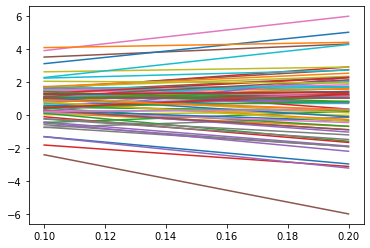

In [15]:
plt.plot(results[0][0], results[0][1][:, :, :, 0].squeeze());

In [16]:
from tvb.contrib.tests.model.model_test import TestPolynomialModel
test = TestPolynomialModel()
test.test_polynomial_model()

1
fix
2025-09-25 17:04:04,104 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-25 17:04:04,109 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
1
fullrandom
2025-09-25 17:04:04,112 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-25 17:04:04,117 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2
fix
2025-09-25 17:04:04,120 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-25 17:04:04,126 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2
fullrandom
2025-09-25 17:04:04,129 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-25 17:04:04,136 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
3
fix
2025-09-25 17:04:04,139 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-25 17:04:04,146